# Delhi AQI Analysis

## Introduction

Air quality is an important environmental and public health concern in Delhi.
This analysis examines air pollution levels using pollutant concentration data and identifies important patterns, variations, and relationships among the major pollutants.

The analysis focuses on understanding pollution trends, seasonal variations, pollutant relationships, and possible environmental factors affecting air quality in Delhi


## Objectives

The main objectives of this analysis are:

- To study the concentration of major air pollutants in Delhi.
- To identify the pollutants with higher concentration levels.
- To analyse changes in pollution levels over time.
- To understand seasonal variations in air pollution.
- To examine relationships between different pollutants.
- To identify periods of relatively high pollution.
- To suggest suitable strategies for improving air quality.

## Dataset Description

The dataset contains air pollution measurements recorded in Delhi at different
dates and times. It includes important pollutants such as carbon monoxide
(CO), nitric oxide (NO), nitrogen dioxide (NO₂), ozone (O₃), sulphur dioxide
(SO₂), particulate matter (PM2.5 and PM10), and ammonia (NH₃).

The date and time information helps us study how pollutant concentrations
change over time and identify important pollution patterns.

## Research Questions

The analysis is designed to investigate the major patterns and factors
associated with air pollution in Delhi. The following research questions
will guide the analysis:

1. Which pollutants have the highest average concentration?
2. How do pollutant concentrations change over time?
3. How does air pollution vary across different seasons?
4. Which pollutants are strongly related to PM2.5 and PM10?
5. Which time periods show relatively high pollutant concentrations?
6. What environmental and geographical factors may influence Delhi's air quality?
7. What strategies can be suggested to improve air quality?

## Methodology

The analysis will be carried out using Python and its data analysis and
visualization libraries. The dataset will first be loaded and examined to
understand its structure and identify missing or duplicate values.

The data will then be cleaned and prepared for analysis. Statistical measures
will be used to understand pollutant concentration levels. Different
visualizations will be created to study trends, seasonal variations, and
relationships between pollutants.

Finally, the results will be interpreted to identify important pollution
patterns and provide practical strategies for improving air quality in Delhi.

## 1. Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("Libraries import successfully!")

Libraries import successfully!


## 2. Loading the Dataset
The Delhi air quality dataset is loaded into a Pandas DataFrame for further analysis. The datset contains data and time information along with measurements of different air pollutants



In [ ]:
df=pd.read_csv('/content/delhiaqi.csv')
print("Dataset loaded successfully")

Dataset loaded successfully


## 3. Initial Data Exploration

The dataset is explored to understand its structure, size, column names, and the type of information available before performing data cleaning and analysis.

In [ ]:
# Display the first five records
df.head()

,date,co,no,no2,o3,so2,pm2_5,pm10,nh3
0,2023-01-01 00:00:00,1655.58,1.66,39.41,5.90,17.88,169.29,194.64,5.83
1,2023-01-01 01:00:00,1869.20,6.82,42.16,1.99,22.17,182.84,211.08,7.66
2,2023-01-01 02:00:00,2510.07,27.72,43.87,0.02,30.04,220.25,260.68,11.40
3,2023-01-01 03:00:00,3150.94,55.43,44.55,0.85,35.76,252.90,304.12,13.55
4,2023-01-01 04:00:00,3471.37,68.84,45.24,5.45,39.10,266.36,322.80,14.19


## 4. Dataset Structure

The shape and column names of the dataset are examined to understand the
number of observations and variables available for analysis.

In [ ]:
# Display the number of rows and columns
print("Dataset shape:", df.shape)

#Display the column names
print("\nColumn names:")
print(df.columns.tolist())

Dataset shape: (561, 9)

Column names:
['date', 'co', 'no', 'no2', 'o3', 'so2', 'pm2_5', 'pm10', 'nh3']


## 5. Checking Data Types

The data types of all columns are examined to ensure that each variable is
stored in the appropriate format before further analysis.

In [ ]:
# Check the data type of each column
df.dtypes

,0
date,object
co,float64
no,float64
no2,float64
o3,float64
so2,float64
pm2_5,float64
pm10,float64
nh3,float64


## 6. Checking for Missing Values

Missing values are checked to determine whether any pollutant measurements or
date-time records are unavailable. This step helps ensure that the analysis
is based on complete and reliable data.

In [ ]:
# Check the number of missing values in each column
df.isnull().sum()

,0
date,0
co,0
no,0
no2,0
o3,0
so2,0
pm2_5,0
pm10,0
nh3,0


## 7. Checking for Duplicate Records

Duplicate records are checked to ensure that the dataset does not contain
repeated observations that could affect the accuracy of the analysis.

In [ ]:
# Count duplicate records
duplicate_count=df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 0


## 8. Statistical Summary

Descriptive statistics are used to understand the central tendency and
variation of the pollutant measurements. The summary includes values such as
count, mean, standard deviation, minimum, and maximum.

In [ ]:
# Generate descriptive statistics for the pollutant columns
df.describe()

,co,no,no2,o3,so2,pm2_5,pm10,nh3
count,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000
mean,3814.942210,51.181979,75.292496,30.141943,64.655936,358.256364,420.988414,26.425062
std,3227.744681,83.904476,42.473791,39.979405,61.073080,227.359117,271.287026,36.563094
min,654.220000,0.000000,13.370000,0.000000,5.250000,60.100000,69.080000,0.630000
25%,1708.980000,3.380000,44.550000,0.070000,28.130000,204.450000,240.900000,8.230000
50%,2590.180000,13.300000,63.750000,11.800000,47.210000,301.170000,340.900000,14.820000
75%,4432.680000,59.010000,97.330000,47.210000,77.250000,416.650000,482.570000,26.350000
max,16876.220000,425.580000,263.210000,164.510000,511.170000,1310.200000,1499.270000,267.510000


## 9. Converting Date and Time

The date column is converted into a datetime format so that time-based
patterns and changes in pollutant concentrations can be analysed accurately.

In [ ]:
# Convert the data column to datetime format
df['date']=pd.to_datetime(df['date'])

# Check the updated data type
print("Date column type:", df['date'].dtype)

Date column type: datetime64[ns]


## 10. Creating Time-Based Features

Additional time-based features are created from the date column to make it
easier to analyse pollution patterns across months, days, and hours.

In [ ]:
# Create time-based columns
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['hour'] = df['date'].dt.hour

# Display the new columns
df[['date', 'year', 'month', 'day', 'hour']].head()

,date,year,month,day,hour
0,2023-01-01 00:00:00,2023,1,1,0
1,2023-01-01 01:00:00,2023,1,1,1
2,2023-01-01 02:00:00,2023,1,1,2
3,2023-01-01 03:00:00,2023,1,1,3
4,2023-01-01 04:00:00,2023,1,1,4


## 11. Average Concentration of Pollutants

The average concentration of each pollutant is calculated to identify which
pollutants generally occur at higher levels in the dataset. This provides a
basic comparison of the major pollutants present in Delhi's air.

In [ ]:
# Calculate the average concentration of each pollutant
pollutants = ['co', 'no', 'no2', 'o3', 'so2', 'pm2_5', 'pm10', 'nh3']

average_pollution = df[pollutants].mean().sort_values(ascending=False)

print("Average pollutant concentrations:")
average_pollution

Average pollutant concentrations:


,0
co,3814.942210
pm10,420.988414
pm2_5,358.256364
no2,75.292496
so2,64.655936
no,51.181979
o3,30.141943
nh3,26.425062


## Interpretation of Average Pollutant Concentrations

The average concentration analysis shows that carbon monoxide (CO) has the
highest average value in the dataset at approximately 3814.94, followed by
PM10 at 420.99 and PM2.5 at 358.26.

Among the remaining pollutants, NO₂ has an average concentration of about
75.29, followed by SO₂ at 64.66, NO at 51.18, O₃ at 30.14, and NH₃ at 26.43.

These values provide an initial comparison of pollutant levels. However,
different pollutants have different measurement scales and health standards,
so their numerical values should not be directly interpreted as meaning that
CO is necessarily more harmful than every other pollutant.

## 12. Average Pollutant Concentration

A bar chart is used to compare the average concentration of the major
pollutants in the dataset. This makes it easier to identify differences in
their average measured levels.

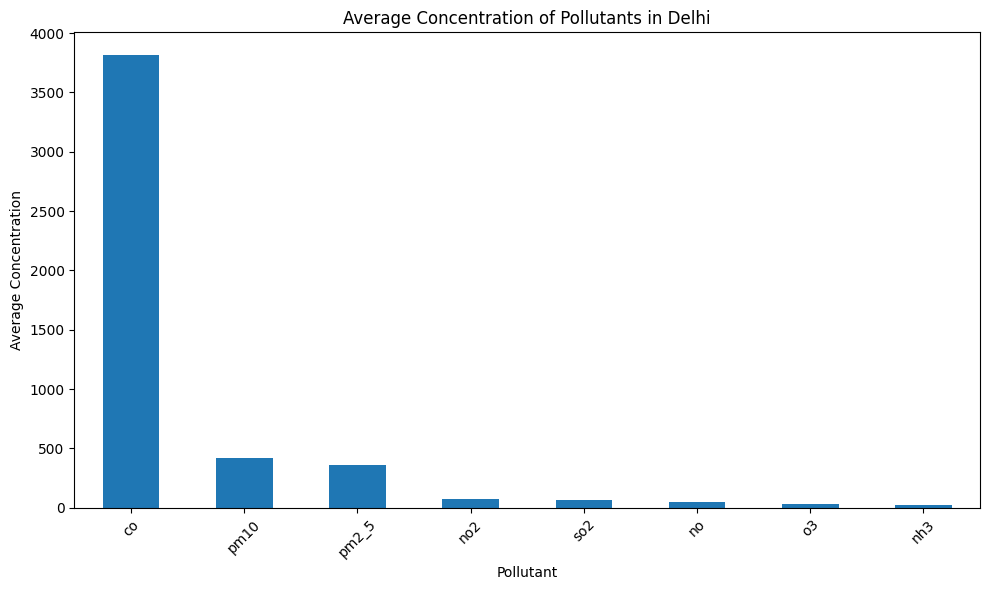

In [ ]:
# Plot average pollutant concentrations
plt.figure(figsize=(10, 6))

average_pollution.plot(kind='bar')

plt.title('Average Concentration of Pollutants in Delhi')
plt.xlabel('Pollutant')
plt.ylabel('Average Concentration')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Interpretation of the Visualization

The bar chart shows clear differences in the average concentrations of the
pollutants. CO has the highest numerical average, followed by PM10 and PM2.5.
The remaining pollutants have comparatively lower numerical averages.

PM10 and PM2.5 are particularly important particulate pollutants because they
represent airborne particles of different sizes. Their relatively high
measured concentrations indicate that particulate pollution is an important
aspect to consider in the Delhi air-quality analysis.

The comparison should be interpreted within the measurement scale of each
pollutant, rather than by comparing the numerical values alone.

## 13. Pollutant Distribution Analysis

The distribution of pollutant concentrations is examined to understand the
spread of the observations and identify whether some pollutants show unusually
high or low values.

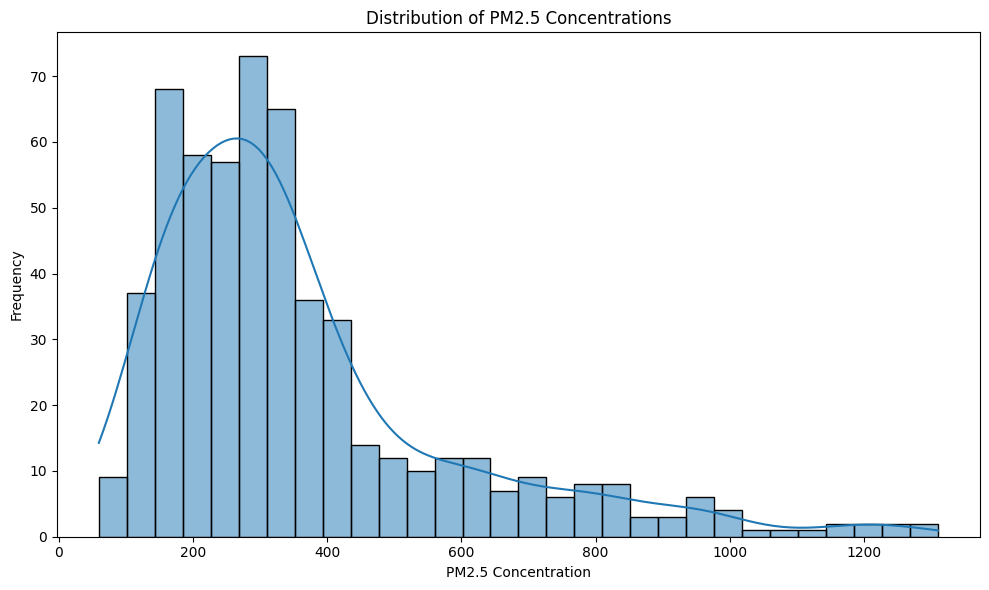

In [ ]:
# Visualize the distribution of selected particulate pollutants
plt.figure(figsize=(10, 6))

sns.histplot(df['pm2_5'], bins=30, kde=True)

plt.title('Distribution of PM2.5 Concentrations')
plt.xlabel('PM2.5 Concentration')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## Interpretation of PM2.5 Distribution

The histogram shows how PM2.5 concentration values are distributed across the
dataset. Most observations are concentrated within a particular range, while
some observations occur at higher concentration levels.

The presence of higher-value observations suggests that PM2.5 levels are not
constant throughout the period and that certain times may experience increased
particulate pollution. Further time-based analysis will help identify when
these higher concentrations occur.

## 14. PM10 Distribution Analysis

The distribution of PM10 concentrations is analysed to understand the spread
of particulate matter levels and identify periods with relatively higher
concentrations.

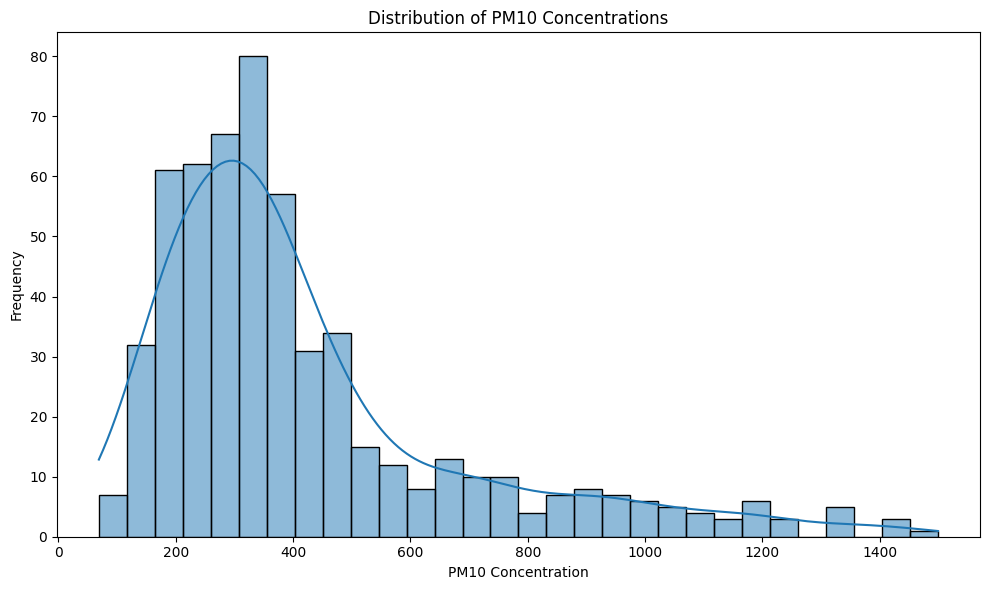

In [ ]:
# Visualize the distribution of PM10
plt.figure(figsize=(10, 6))

sns.histplot(df['pm10'], bins=30, kde=True)

plt.title('Distribution of PM10 Concentrations')
plt.xlabel('PM10 Concentration')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## Interpretation of PM10 Distribution

The histogram shows the spread of PM10 concentration values in the dataset.
Most observations occur within a lower-to-moderate range, while some
observations extend to higher concentration levels.

This indicates that PM10 concentrations vary across different observations.
The higher values may correspond to periods of increased particulate pollution.
Time-based analysis will help us understand when these changes occur.

## 15. Monthly Pollution Analysis

Monthly average pollutant concentrations are calculated to identify changes
in air pollution across different months. This helps us understand whether
certain months show consistently higher or lower pollution levels.

In [ ]:
# Calculate monthly average concentrations
monthly_pollution = df.groupby('month')[pollutants].mean()

monthly_pollution.head()

,co,no,no2,o3,so2,pm2_5,pm10,nh3
month,,,,,,,,
1,3814.94221,51.181979,75.292496,30.141943,64.655936,358.256364,420.988414,26.425062


## Interpretation of Monthly Analysis

The dataset contains observations for January only. Therefore, a comparison
of pollution levels across different months or seasons is not possible using
this dataset.

Further analysis will focus on the available time-based information and the
relationships between different pollutants.

## 16. Hourly Pollution Analysis

Since the dataset contains observations from January only, monthly and seasonal
comparisons are limited. Therefore, hourly analysis is used to understand how
pollution levels change during different times of the day.

The hourly averages of PM2.5 and PM10 are calculated because particulate matter
is an important part of air-quality analysis.

In [ ]:
# Calculate hourly average PM2.5 and PM10
hourly_pollution = df.groupby('hour')[['pm2_5', 'pm10']].mean()

# Display the hourly averages
hourly_pollution

,pm2_5,pm10
hour,,
0,284.571250,314.638750
1,295.627083,328.781250
2,336.278750,382.432917
3,362.630417,416.650000
4,334.481667,386.673333
5,332.568750,388.529583
6,332.872500,388.692083
7,216.307917,245.275417
8,194.313750,218.862083


## 17. Hourly Pollution Visualization

A line chart is used to visualize the hourly average concentrations of PM2.5
and PM10. This helps identify the hours during which particulate pollution
is relatively higher or lower.

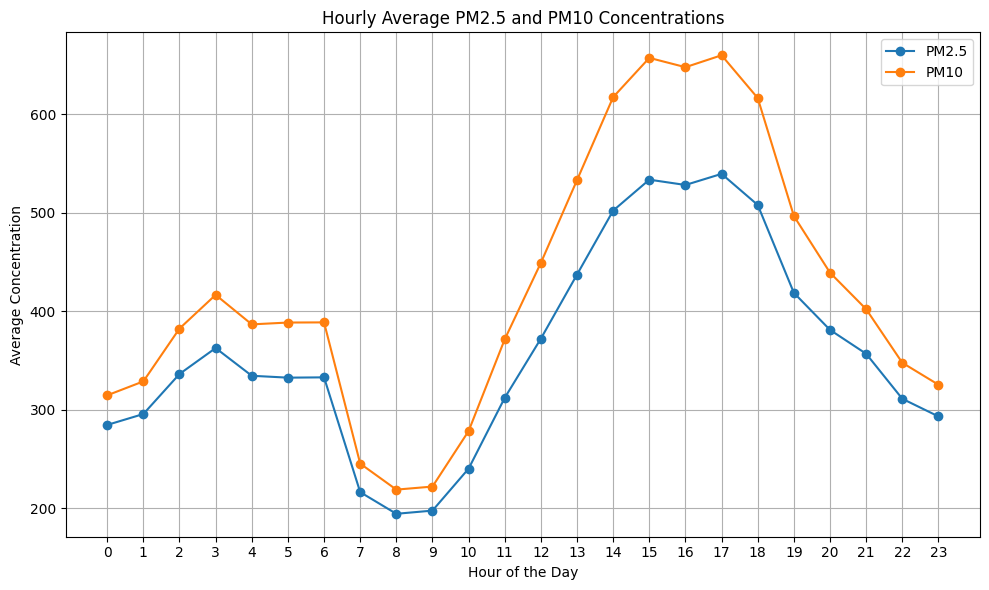

In [ ]:
# Plot hourly average PM2.5 and PM10
plt.figure(figsize=(10, 6))

plt.plot(hourly_pollution.index, hourly_pollution['pm2_5'],
         marker='o', label='PM2.5')

plt.plot(hourly_pollution.index, hourly_pollution['pm10'],
         marker='o', label='PM10')

plt.title('Hourly Average PM2.5 and PM10 Concentrations')
plt.xlabel('Hour of the Day')
plt.ylabel('Average Concentration')
plt.xticks(range(24))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 18. Interpretation of Hourly Pollution

The hourly analysis shows that PM2.5 and PM10 concentrations change noticeably
throughout the day. Both pollutants follow a similar overall pattern, with
higher values observed during the afternoon and evening hours.

The highest average PM2.5 concentration is observed around 17:00, while the
highest average PM10 concentration is also observed around 17:00.

The lowest concentrations for both pollutants occur during the morning hours,
particularly around 08:00.

The similar movement of PM2.5 and PM10 suggests that particulate pollution
levels tend to change together during different hours of the day.

These observations describe patterns in this dataset and should not be
interpreted as proof of a specific cause without additional environmental or
meteorological data.

## 19. Correlation Between Pollutants

Correlation analysis is used to understand the relationship between different
air pollutants. A positive correlation means that two pollutants tend to
increase or decrease together, while a negative correlation indicates an
opposite relationship.

The correlation matrix will help identify which pollutants have stronger
relationships with PM2.5 and PM10.

In [ ]:
# Calculate the correlation matrix
correlation_matrix = df[pollutants].corr()

# Display the correlation matrix
correlation_matrix

,co,no,no2,o3,so2,pm2_5,pm10,nh3
co,1.000000,0.969740,0.776402,-0.463082,0.716831,0.953083,0.966801,0.826299
no,0.969740,1.000000,0.702201,-0.377813,0.734503,0.888810,0.903339,0.823638
no2,0.776402,0.702201,1.000000,-0.407177,0.734961,0.698696,0.720050,0.700254
o3,-0.463082,-0.377813,-0.407177,1.000000,-0.049158,-0.450458,-0.468477,-0.299663
so2,0.716831,0.734503,0.734961,-0.049158,1.000000,0.648996,0.658325,0.843635
pm2_5,0.953083,0.888810,0.698696,-0.450458,0.648996,1.000000,0.994088,0.720303
pm10,0.966801,0.903339,0.720050,-0.468477,0.658325,0.994088,1.000000,0.754468
nh3,0.826299,0.823638,0.700254,-0.299663,0.843635,0.720303,0.754468,1.000000


## 20. Correlation Heatmap

A heatmap is used to present the correlation matrix visually. The colour
intensity helps identify stronger and weaker relationships between pollutants.

Values closer to +1 indicate a strong positive relationship, values closer to
-1 indicate a strong negative relationship, and values near 0 indicate a weak
linear relationship.

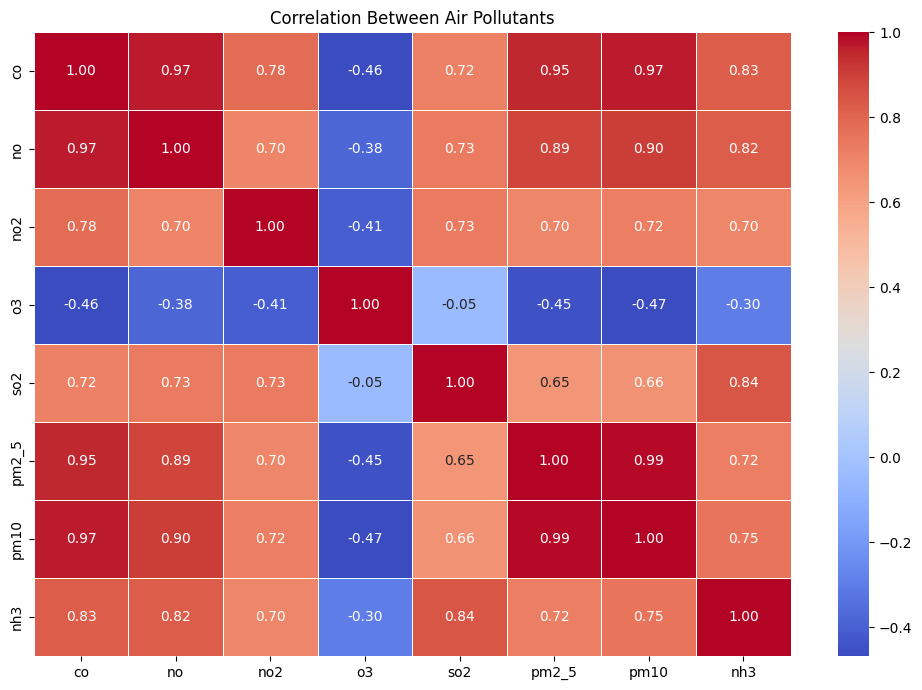

In [ ]:
# Plot the correlation heatmap
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Between Air Pollutants')
plt.tight_layout()
plt.show()

## 21. Interpretation of Correlation Heatmap

The correlation heatmap shows the relationships between the different air
pollutants in the dataset.

PM2.5 and PM10 show a strong positive relationship, indicating that their
concentrations tend to increase and decrease together.

Several other pollutants also show positive relationships with particulate
matter, although the strength of these relationships varies.

The heatmap helps identify pollutants that may follow similar patterns and
provides useful information for understanding the overall pollution behaviour.

Correlation indicates an association between variables, but it does not by
itself prove that one pollutant causes another.

## 22. Identifying High Pollution Periods

The observations with relatively high PM2.5 and PM10 concentrations are
identified to determine the periods with greater particulate pollution.

The top observations are selected based on PM2.5 concentration and their
corresponding PM10 values are examined.

In [ ]:
# Select the 10 observations with the highest PM2.5 concentrations
high_pollution = df.nlargest(10, 'pm2_5')[['date', 'pm2_5', 'pm10']]

# Display the high-pollution observations
high_pollution

,date,pm2_5,pm10
449,2023-01-19 17:00:00,1310.20,1499.27
308,2023-01-13 20:00:00,1278.35,1342.18
307,2023-01-13 19:00:00,1232.62,1355.20
448,2023-01-19 16:00:00,1228.04,1415.28
306,2023-01-13 18:00:00,1225.39,1448.70
309,2023-01-13 21:00:00,1204.33,1238.17
305,2023-01-13 17:00:00,1174.70,1448.28
450,2023-01-19 18:00:00,1170.46,1351.85
447,2023-01-19 15:00:00,1142.61,1335.34
304,2023-01-13 16:00:00,1074.91,1337.24


## 23. Interpretation of High Pollution Periods

The analysis identifies the observations with the highest PM2.5
concentrations in the dataset. These observations also show relatively high
PM10 concentrations.

This indicates that periods with higher PM2.5 levels are generally associated
with increased PM10 levels as well. The identified dates and times represent
important high-pollution periods within the available dataset.

These results can help focus further investigation on the conditions present
during high-pollution periods.

## 24. Daily Pollution Analysis

Daily average pollutant concentrations are calculated to understand how
particulate pollution changes from one day to another.

This analysis helps identify days with relatively higher or lower pollution
levels during the available period.

In [ ]:
# Calculate daily average PM2.5 and PM10
daily_pollution = df.groupby(df['date'].dt.date)[['pm2_5', 'pm10']].mean()

# Display the daily averages
daily_pollution

,pm2_5,pm10
date,,
2023-01-01,443.940000,535.040417
2023-01-02,698.104167,830.148750
2023-01-03,381.810417,434.333750
2023-01-04,304.021667,350.490833
2023-01-05,423.604583,496.787917
2023-01-06,418.079583,494.499583
2023-01-07,265.905000,294.637917
2023-01-08,354.217917,396.266667
2023-01-09,557.806250,650.216667


## 25. Daily PM2.5 and PM10 Trend

A line chart is used to visualize the daily average concentrations of PM2.5
and PM10. This helps identify changes in particulate pollution across the
available days in the dataset.

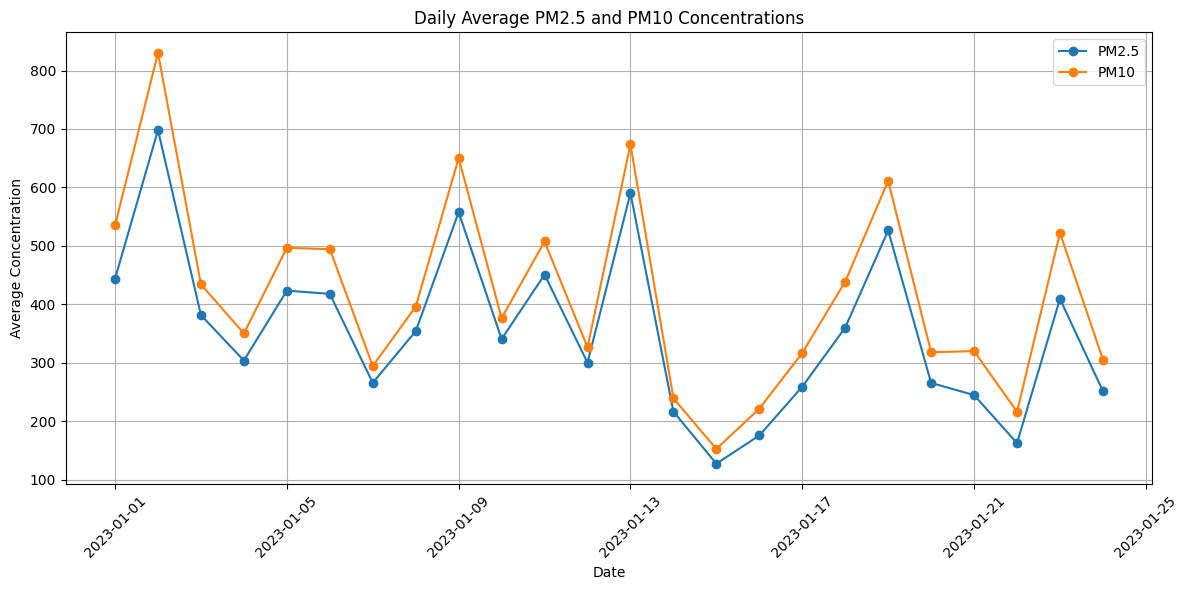

In [ ]:
# Plot daily average PM2.5 and PM10
plt.figure(figsize=(12, 6))

plt.plot(daily_pollution.index, daily_pollution['pm2_5'],
         marker='o', label='PM2.5')

plt.plot(daily_pollution.index, daily_pollution['pm10'],
         marker='o', label='PM10')

plt.title('Daily Average PM2.5 and PM10 Concentrations')
plt.xlabel('Date')
plt.ylabel('Average Concentration')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 26. Interpretation of Daily Pollution Trend

The daily trend shows that PM2.5 and PM10 concentrations vary across the
available days in January.

Both pollutants generally follow a similar pattern, with increases and
decreases occurring on several days. This is consistent with the strong
relationship observed between PM2.5 and PM10 in the correlation analysis.

The variation between days indicates that particulate pollution is not
constant and may be influenced by changing environmental conditions.

Since the dataset covers only a limited period, these observations should be
considered specific to the available data rather than representative of all
days or seasons in Delhi.

## 27. Pollutant-wise Comparison

The average concentrations of all pollutants are compared to understand the
overall pollution profile of the dataset.

This comparison helps identify the pollutants that have relatively higher
measured concentrations and should receive attention during further analysis.

In [ ]:
# Create a summary of average pollutant concentrations
pollutant_summary = average_pollution.reset_index()

pollutant_summary.columns = ['Pollutant', 'Average Concentration']

pollutant_summary

,Pollutant,Average Concentration
0,co,3814.942210
1,pm10,420.988414
2,pm2_5,358.256364
3,no2,75.292496
4,so2,64.655936
5,no,51.181979
6,o3,30.141943
7,nh3,26.425062


## 28. Key Findings

The major findings from the Delhi air-quality analysis are:

1. CO has the highest numerical average concentration among the pollutants
   included in the dataset, followed by PM10 and PM2.5.

2. PM2.5 and PM10 show noticeable variation across different hours of the day.

3. The highest average PM2.5 and PM10 levels occur around the afternoon and
   evening period in the available data.

4. PM2.5 and PM10 show a strong positive relationship,

## 29. Environmental and Geographical Factors

Delhi's air quality can be influenced by several environmental and
geographical factors. Major sources of air pollution may include vehicle
emissions, industrial activities, construction and road dust, biomass and
waste burning, and other local activities.

Weather conditions such as wind speed, temperature, rainfall, and atmospheric
stability can also affect the dispersion and concentration of pollutants.

Delhi's geographical setting and surrounding regions can further influence
pollution levels, especially when pollutants are not dispersed effectively.

However, the present dataset does not contain geographical, weather, or
monitoring-station information. Therefore, these factors are discussed
qualitatively and cannot be directly tested using this dataset.

## 30. Strategies to Improve Air Quality

Based on the patterns observed in the analysis, several strategies can be
suggested to improve air quality in Delhi:

1. Promote public transport and encourage the use of cleaner vehicles to
   reduce vehicle-related emissions.

2. Control construction and road dust through proper covering, regular
   cleaning, and dust-management practices.

3. Strengthen monitoring and control of industrial emissions.

4. Reduce open burning of waste and promote proper waste collection and
   disposal.

5. Increase green spaces and tree plantation where suitable to support a
   healthier urban environment.

6. Use air-quality monitoring data to identify high-pollution periods and
   support timely pollution-control measures.

7. Combine pollution monitoring with weather information to better understand
   conditions that contribute to pollutant accumulation.

## 31. Conclusion

This analysis examined the air-quality data available for Delhi using Python,
Pandas, Matplotlib, and Seaborn. The analysis included data exploration,
cleaning checks, descriptive statistics, pollutant comparison, distribution
analysis, hourly patterns, daily trends, and correlation analysis.

The results show that particulate pollutants, particularly PM2.5 and PM10,
vary considerably across different observations and generally follow similar
patterns. The hourly analysis indicates higher particulate concentrations
during the afternoon and evening in the available data.

The analysis also identified important limitations. The dataset contains
observations from January only and does not include geographical or weather
information. Therefore, seasonal and geographical comparisons cannot be
reliably performed using this dataset alone.

Overall, the analysis demonstrates how data analysis and visualization can be
used to identify pollution patterns and support data-driven air-quality
management strategies.